# <font color="#F5AD27">__PI M5 - Fundamentos de nube y ciencia de datos de producción__</font>
## <font color="#F5AD27">__EDA__</font>


---

### <font color="#F5AD27">__Importación de librerías__</font>
---

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# importar funcion loadData desde cargar_datos.py
from cargar_datos import loadData

### <font color="#F5AD27">__Carga de datos__</font>

In [3]:
# Cargar el dataset con la función loadData
df = loadData()


### <font color="#F5AD27">__Exploración del dataset__</font>
---

In [4]:
# Breve panorama del dataset
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [5]:
# Cantidad de registros y atributos de la selección
print(f'🔍La cantidad de registros del dataset es de: {df.shape[0]}.')
print(f'🔍La cantidad de atributos del dataset es de: {df.shape[1]}.')

🔍La cantidad de registros del dataset es de: 10763.
🔍La cantidad de atributos del dataset es de: 23.


In [6]:
# Identificando si hay valores duplicados
duplicados = df.duplicated().any()

if duplicados:
    print("Hay registros duplicados en el DataFrame.")
else:
    print("No hay registros duplicados en el DataFrame.")

No hay registros duplicados en el DataFrame.


In [7]:
# Observamos información general del Dataset y prsencia de valores nulos
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2),
    'valores_únicos': df.nunique()
})

print(" --- DESCRIPCIÓN GENERAL ---")
print(info.to_string())

 --- DESCRIPCIÓN GENERAL ---
                                        dtype  nulos  nulos_%  valores_únicos
tipo_credito                            int64      0     0.00               6
fecha_prestamo                 datetime64[ns]      0     0.00           10758
capital_prestado                      float64      0     0.00            7306
plazo_meses                             int64      0     0.00              18
edad_cliente                            int64      0     0.00              54
tipo_laboral                           object      0     0.00               2
salario_cliente                         int64      0     0.00            1385
total_otros_prestamos                   int64      0     0.00            1538
cuota_pactada                           int64      0     0.00            9836
puntaje                               float64      0     0.00             248
puntaje_datacredito                   float64      6     0.06             315
cant_creditosvigentes              

##### <font color="#F5AD27">__Caracterización de variables__</font>

| Variable | Tipo de variable | Descripcion |
|---|---|---|
| tipo_credito | Nominal politómico | Código de producto crediticio |
| fecha_prestamo | Fecha | Fecha de origen del crédito |
| capital_prestado | Numérico continuo | Monto desembolsado |
| plazo_meses | Numérico discreto | Duración del crédito |
| edad_cliente | Numérico discreto | Edad del solicitante |
| tipo_laboral | Nominal dicotómico | Empleado / Independiente |
| salario_cliente | Numérico continuo | Ingreso mensual declarado |
| total_otros_prestamos | Numérico continuo | Carga de deuda externa |
| cuota_pactada | Numérico continuo | Pago mensual acordado |
| puntaje | Numérico continuo | Score interno (0-100) |
| puntaje_datacredito | Numérico continuo | Score buró de crédito |
| cant_creditosvigentes | Numérico discreto | Créditos activos |
| huella_consulta | Numérico discreto | Consultas al buró |
| saldo_mora | Numérico continuo | Deuda en mora |
| saldo_total | Numérico continuo | Saldo total de la obligación |
| saldo_principal | Numérico continuo | Capital pendiente |
| saldo_mora_codeudor | Numérico continuo | Mora del codeudor |
| creditos_sectorFinanciero | Numérico discreto | Créditos en sector financiero |
| creditos_sectorCooperativo | Numérico discreto | Créditos en cooperativas |
| creditos_sectorReal | Numérico discreto | Créditos en sector real |
| promedio_ingresos_datacredito | Numérico continuo | Ingresos reportados al buró |
| tendencia_ingresos | Ordinal politómico | Creciente / Estable / Decreciente |
| **Pago_atiempo** | **Nominal dicotómico (TARGET)** | **1 = paga puntual, 0 = mora** |

NULOS POR COLUMNA:
                               nulos      %
puntaje_datacredito                6   0.06
saldo_mora                       156   1.45
saldo_total                      156   1.45
saldo_principal                  405   3.76
saldo_mora_codeudor              590   5.48
promedio_ingresos_datacredito   2930  27.22
tendencia_ingresos              2932  27.24


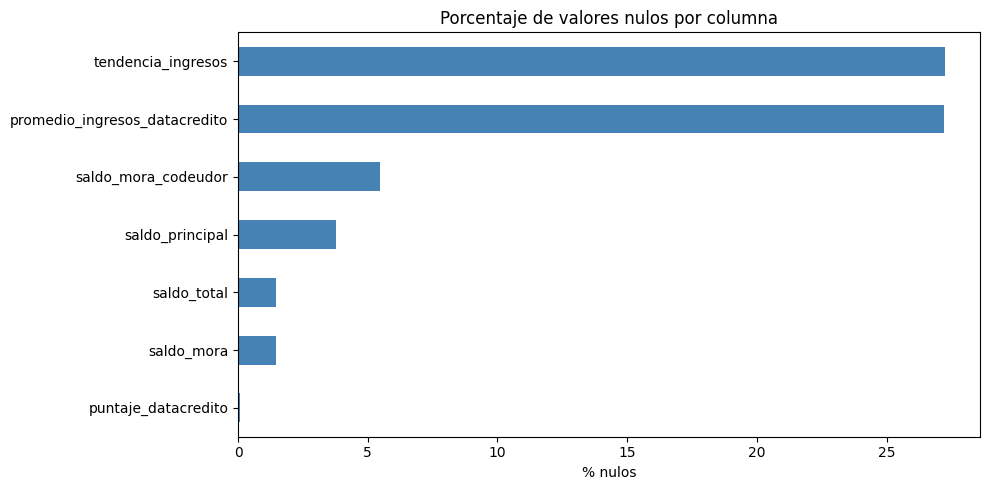

In [8]:
# Unificamos representaciones de nulos
for col in df.select_dtypes('object').columns:
    # Reemplazo de strings vacíos o variantes de valor nulo
    df[col] = df[col].replace(['', ' ', 'NA', 'N/A', 'nan', 'None', '-'], np.nan)

print("NULOS POR COLUMNA:")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

# Visualización de nulos
plt.figure(figsize=(10, 5))
nulos_pct[nulos_pct > 0].sort_values().plot(kind='barh', color='steelblue')
plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('% nulos')
plt.tight_layout()
plt.show()

In [9]:
# Correccion de tipos de datos
# tipo_credito → categórico 
df['tipo_credito'] = df['tipo_credito'].astype('category')

# fecha_prestamo extraemos features útiles
df['año_prestamo'] = df['fecha_prestamo'].dt.year
df['mes_prestamo'] = df['fecha_prestamo'].dt.month

# tipo_laboral y tendencia_ingresos → category
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
df['tendencia_ingresos'] = pd.Categorical(
    df['tendencia_ingresos'],
    categories=['Decreciente', 'Estable', 'Creciente'],
    ordered=True  # ordinal
)

# Pago_atiempo → booleano / category (variable target)
df['Pago_atiempo'] = df['Pago_atiempo'].astype('category')

print("Tipos de variable actualizados:")
print(df.dtypes)
print()
print("Distribución de la variable TARGET (Pago_atiempo):")
print(df['Pago_atiempo'].value_counts())
print(df['Pago_atiempo'].value_counts(normalize=True).mul(100).round(2))

Tipos de variable actualizados:
tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio

__🔍Observaciones:__   
El dataset está desbalanceado — ~95% clase 1 (pago puntual) y ~5% clase 0 (mora).

In [21]:
# Cuántos registros tienen salario = 0?
print(f"Registros con salario_cliente = 0: {(df['salario_cliente'] == 0).sum()}")

Registros con salario_cliente = 0: 24


__🔍Observaciones:__   
Un salario = 0 no es válido y existen 24 registros con salario = 0.

#### <font color="#F5AD27">__Resumen estadístico de los datos__</font>
---

In [10]:
df.describe().round(2)

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,año_prestamo,mes_prestamo
count,10763,10763.00,10763.00,10763.00,1.076300e+04,1.076300e+04,10763.00,10763.00,10757.00,10763.00,...,10607.00,10607.00,10358.00,10173.00,10763.00,10763.00,10763.00,7833.00,10763.00,10763.00
mean,2025-04-16 23:06:02.111121664,2434315.00,10.58,43.95,1.721643e+07,6.238870e+06,243617.41,91.17,780.79,5.73,...,7.75,45937.41,40346.17,0.26,2.78,0.27,1.30,2005156.81,2024.89,5.27
min,2024-11-26 09:17:04,360000.00,2.00,19.00,0.000000e+00,0.000000e+00,23944.00,-38.01,-7.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2024.00,1.00
25%,2025-01-20 17:33:07.500000,1224831.00,6.00,33.00,2.000000e+06,5.000000e+05,121041.50,95.23,757.00,3.00,...,0.00,2898.00,2690.00,0.00,1.00,0.00,0.00,925157.00,2025.00,2.00
50%,2025-03-27 16:23:12,1921920.00,10.00,42.00,3.000000e+06,1.000000e+06,182863.00,95.23,791.00,5.00,...,0.00,16178.00,14442.50,0.00,2.00,0.00,1.00,1204496.00,2025.00,4.00
75%,2025-06-16 13:27:58,3084840.00,12.00,53.00,4.875808e+06,2.000000e+06,287833.50,95.23,825.00,8.00,...,0.00,52982.00,47632.25,0.00,4.00,0.00,2.00,2231859.00,2025.00,8.00
max,2026-04-26 18:43:52,41444152.80,90.00,123.00,2.200000e+10,6.787675e+09,3816752.00,95.23,999.00,62.00,...,12534.00,5116066.00,1562285.00,2145.00,51.00,13.00,25.00,38106581.00,2026.00,12.00
std,NaN,1909642.76,6.63,15.06,3.554767e+08,1.184183e+08,210493.69,16.47,104.88,3.98,...,225.96,106269.79,71242.44,21.77,2.75,0.72,1.82,2144116.15,0.38,3.72


## <font color="#F5AD27">__EDA__</font>

### <font color="#F5AD27">__Análisis Univariado__</font>
---

#### <font color="#F5AD27">__Variables Numéricas__</font>
---

In [11]:
# Variables numéricas
num_cols = df.select_dtypes(include='number').columns.tolist()

# Variables categóricas
cat_cols = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
df[num_cols].describe().T.assign(
    IQR=lambda x: x['75%'] - x['25%'],
    skewness=df[num_cols].skew(),
    kurtosis=df[num_cols].kurt()
).round(2)

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis
capital_prestado,10763.0,2434315.00,1.909643e+06,360000.00,1224831.00,1921920.00,3084840.00,4.144415e+07,1860009.00,3.72,35.32
plazo_meses,10763.0,10.58,6.630000e+00,2.00,6.00,10.00,12.00,9.000000e+01,6.00,2.46,7.78
edad_cliente,10763.0,43.95,1.506000e+01,19.00,33.00,42.00,53.00,1.230000e+02,20.00,1.93,7.87
salario_cliente,10763.0,17216431.46,3.554767e+08,0.00,2000000.00,3000000.00,4875808.00,2.200000e+10,2875808.00,43.78,2211.23
total_otros_prestamos,10763.0,6238869.65,1.184183e+08,0.00,500000.00,1000000.00,2000000.00,6.787675e+09,1500000.00,38.46,1719.28
cuota_pactada,10763.0,243617.41,2.104937e+05,23944.00,121041.50,182863.00,287833.50,3.816752e+06,166792.00,3.79,26.65
puntaje,10763.0,91.17,1.647000e+01,-38.01,95.23,95.23,95.23,9.523000e+01,0.00,-4.87,24.08
puntaje_datacredito,10757.0,780.79,1.048800e+02,-7.00,757.00,791.00,825.00,9.990000e+02,68.00,-5.64,39.44
cant_creditosvigentes,10763.0,5.73,3.980000e+00,0.00,3.00,5.00,8.00,6.200000e+01,5.00,1.80,8.62
huella_consulta,10763.0,4.23,3.060000e+00,0.00,2.00,4.00,6.00,2.900000e+01,4.00,1.49,4.00


__🔍Observaciones:__   
Varios de los atributos (en mayor cantidad) presentan una asimetría positiva con presencia de outliers hacia valores altos, como salario_cliente, total_otros_prestamos, saldo_moral, saldo_mora_codeudor, entre otros; otras en menor medida presentan asimetría negativa con presencia de outliers hacia valores bajos, como puntaje, puntaje_datacredito, año_prestamo.

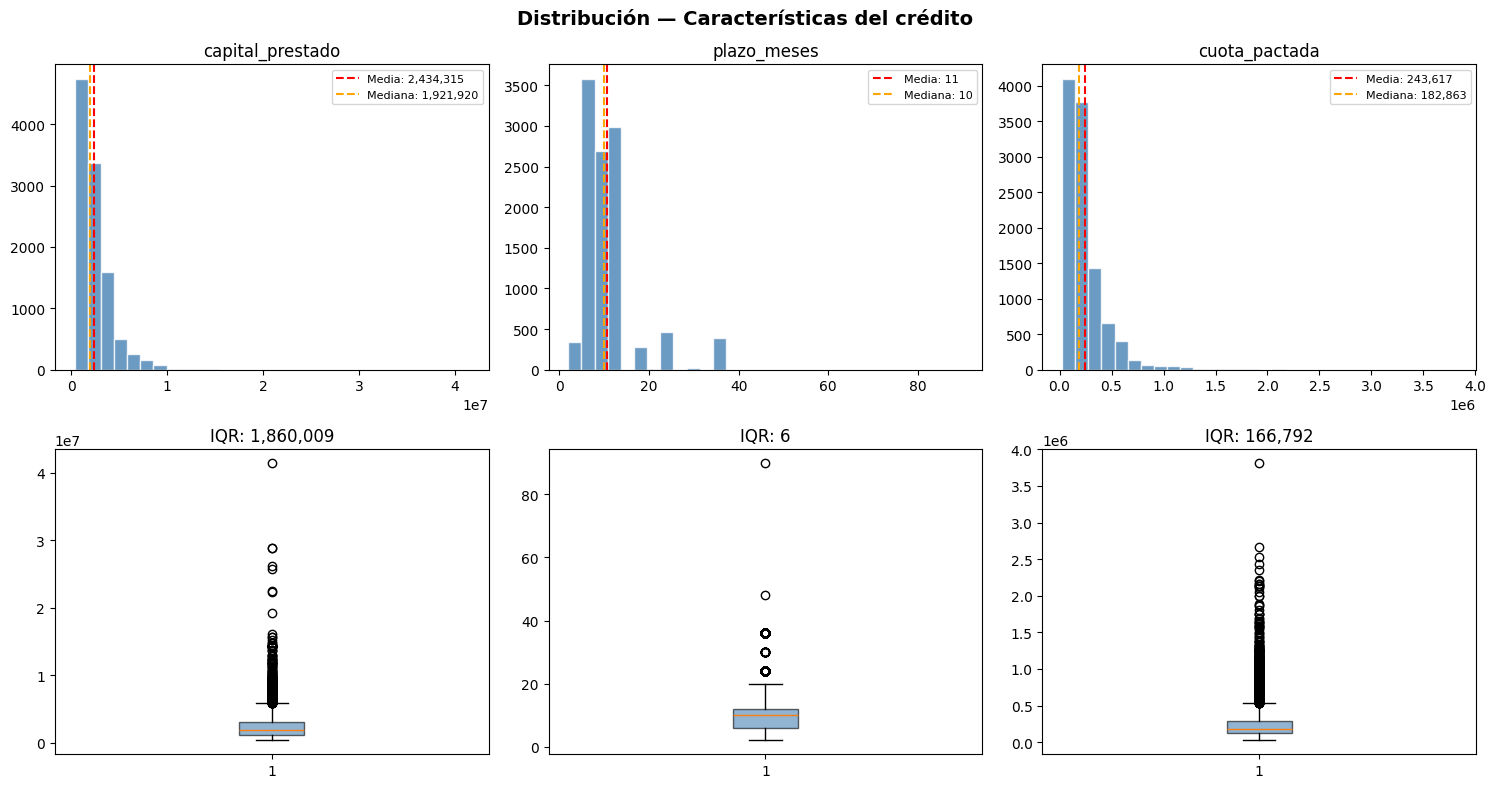

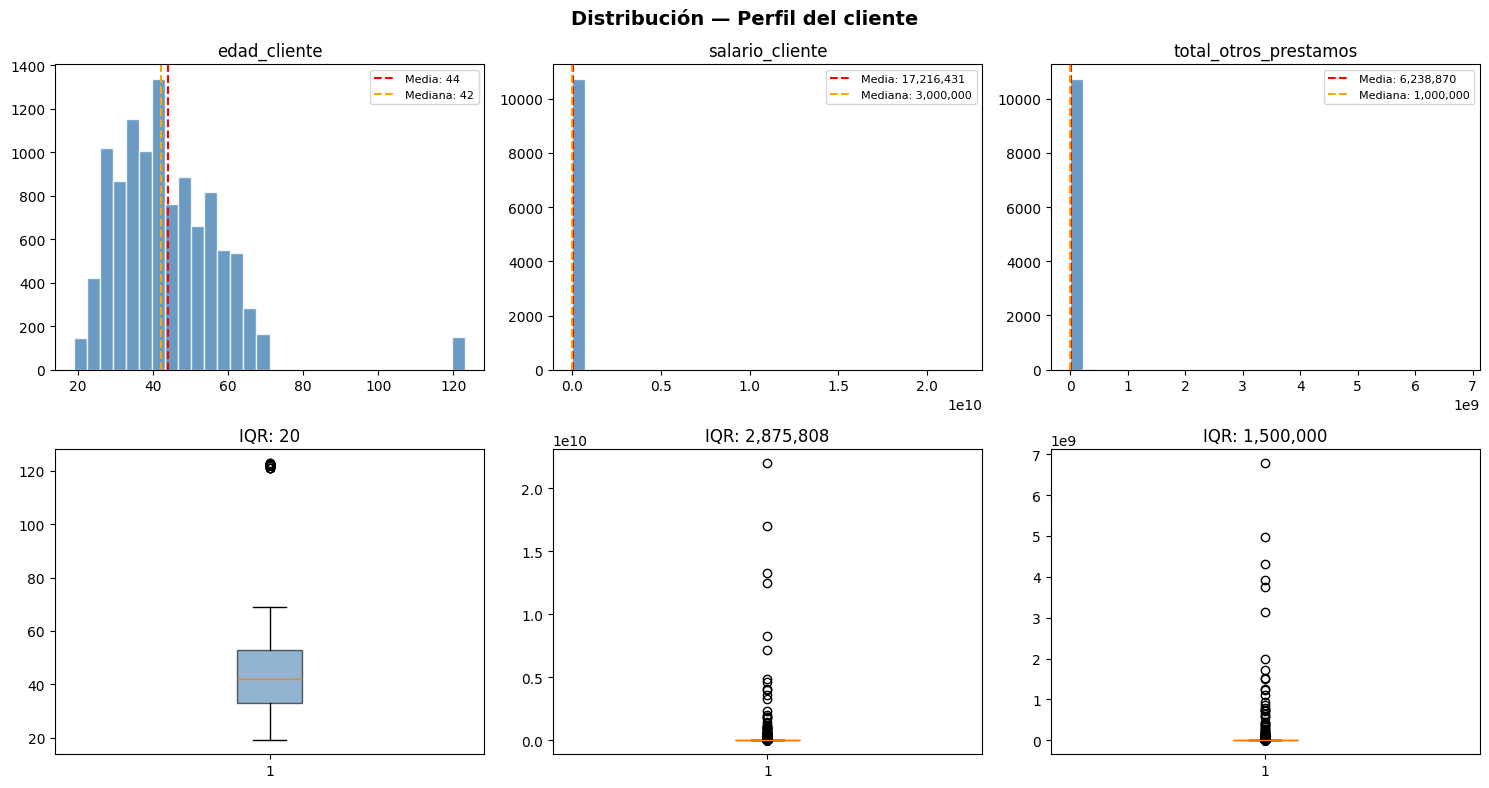

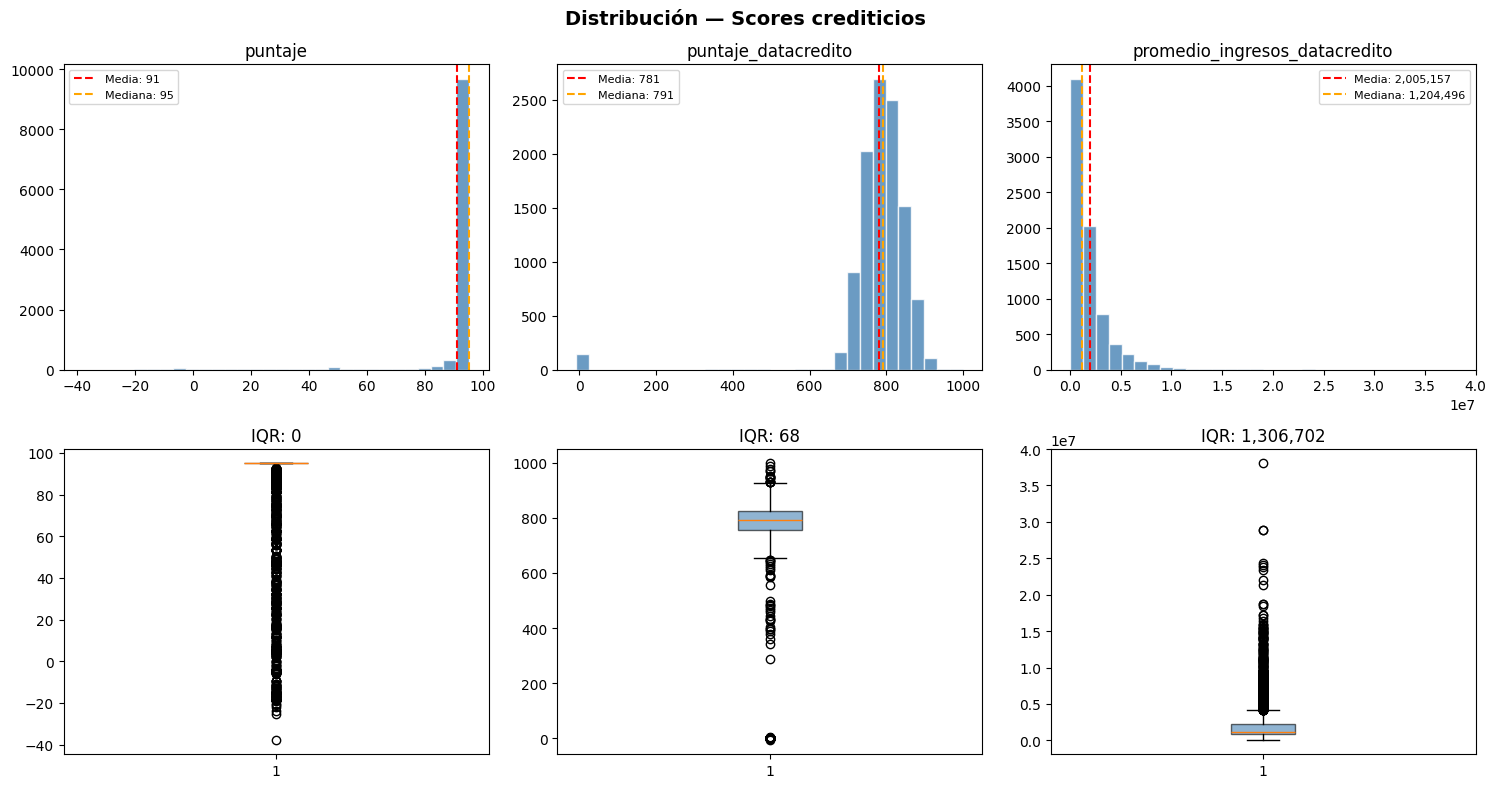

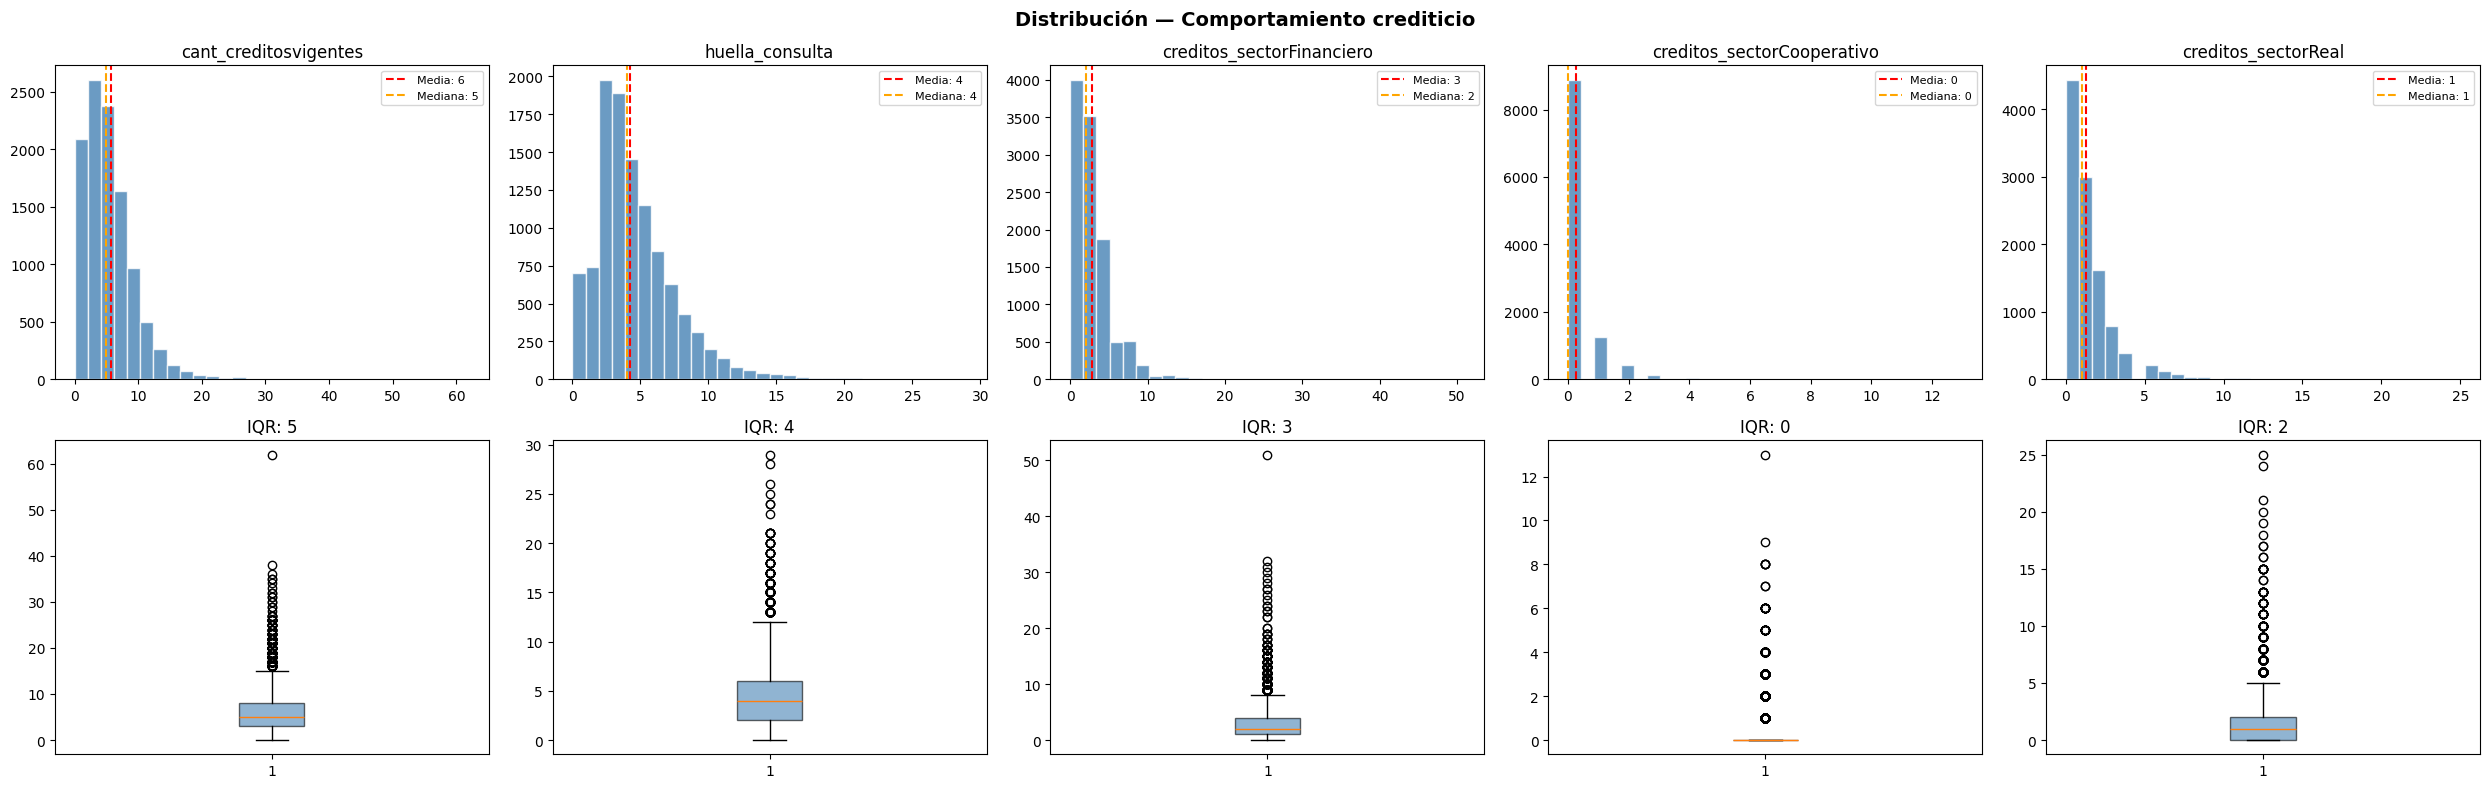

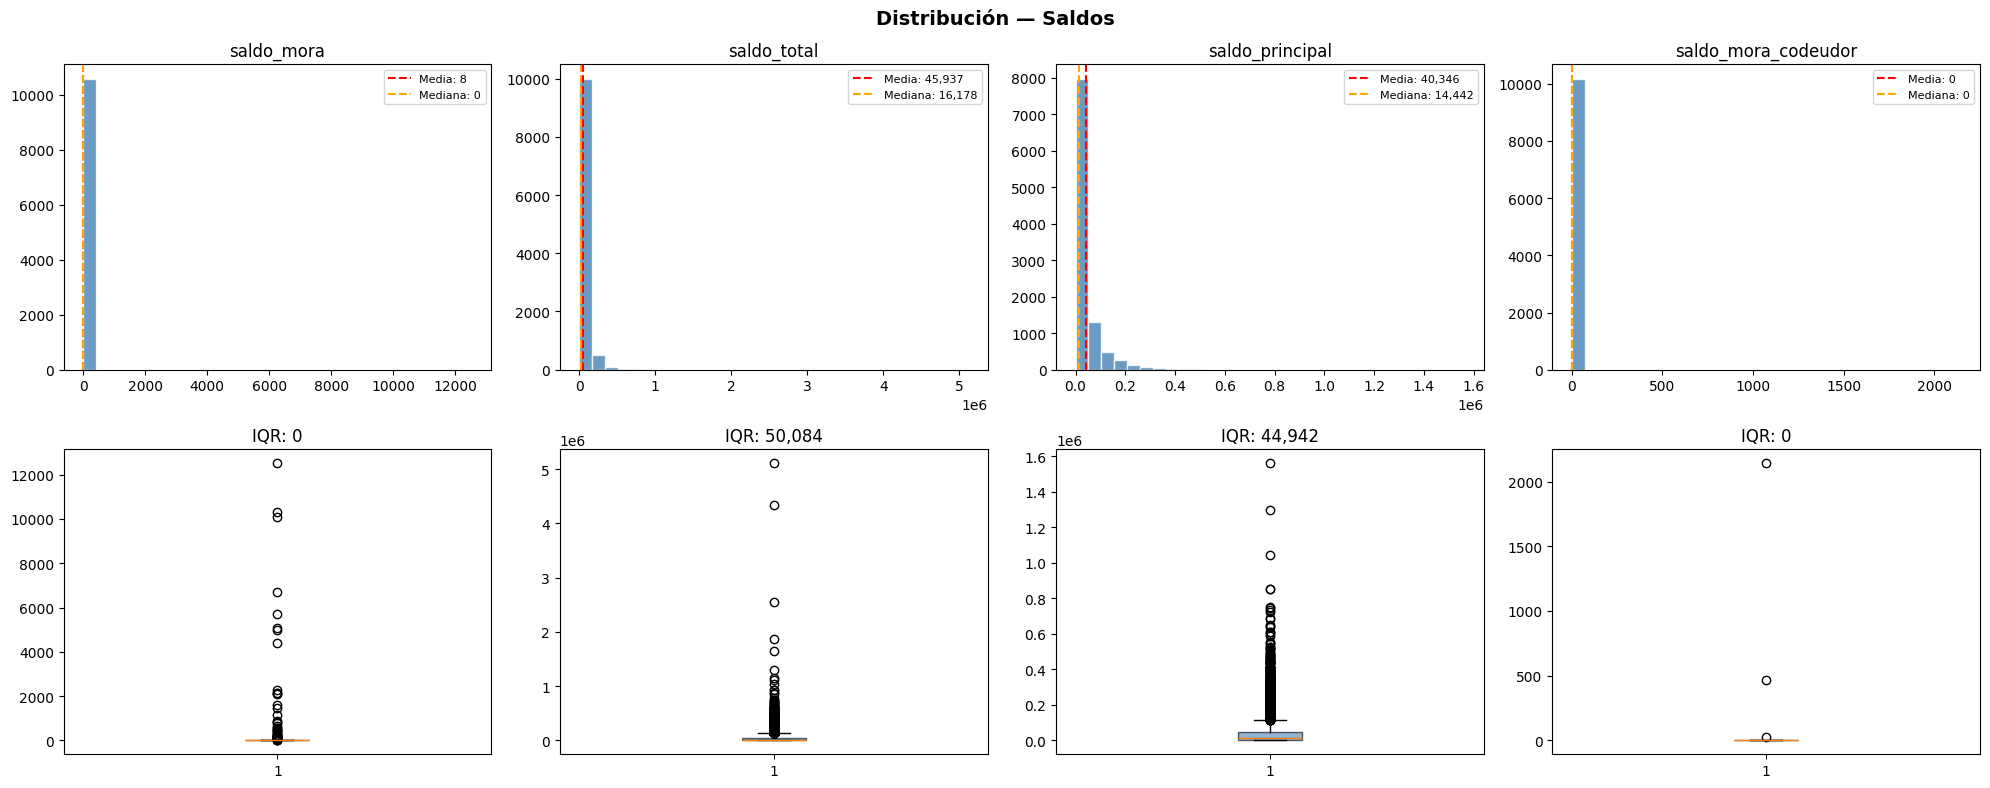

In [12]:
# Histogramas + boxplots
# Agrupamos las numéricas en grupos para mejor visualización 
grupos = {
    'Características del crédito': 
        ['capital_prestado', 'plazo_meses', 'cuota_pactada'],
    'Perfil del cliente': 
        ['edad_cliente', 'salario_cliente', 'total_otros_prestamos'],
    'Scores crediticios': 
        ['puntaje', 'puntaje_datacredito', 'promedio_ingresos_datacredito'],
    'Comportamiento crediticio': 
        ['cant_creditosvigentes', 'huella_consulta',
         'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal'],
    'Saldos': 
        ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor']
}

for grupo, cols in grupos.items():
    fig, axes = plt.subplots(2, len(cols), figsize=(5 * len(cols), 8))
    fig.suptitle(f'Distribución — {grupo}', fontsize=14, fontweight='bold')
    
    for i, col in enumerate(cols):
        data = df[col].dropna()
        
        # Histograma
        axes[0, i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[0, i].axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():,.0f}')
        axes[0, i].axvline(data.median(), color='orange', linestyle='--', label=f'Mediana: {data.median():,.0f}')
        axes[0, i].set_title(col)
        axes[0, i].legend(fontsize=8)
        
        # Boxplot
        axes[1, i].boxplot(data, vert=True, patch_artist=True,
                           boxprops=dict(facecolor='steelblue', alpha=0.6))
        axes[1, i].set_title(f'IQR: {data.quantile(0.75) - data.quantile(0.25):,.0f}')
    
    plt.tight_layout()
    plt.show()

In [13]:
# Tabla estadística detallada por variable numérica
def estadisticas_univariable(df, col):
    """Retorna un resumen estadístico completo para una variable numérica."""
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    skew = data.skew()
    
    # Tipo de distribución aproximado
    if abs(skew) < 0.5:
        dist = 'Aproximadamente simétrica'
    elif skew > 1:
        dist = 'Asimétrica positiva (cola derecha)'
    elif skew < -1:
        dist = 'Asimétrica negativa (cola izquierda)'
    else:
        dist = 'Moderadamente asimétrica'
    
    return {
        'media': data.mean(),
        'mediana': data.median(),
        'moda': data.mode().iloc[0] if not data.mode().empty else np.nan,
        'min': data.min(),
        'max': data.max(),
        'rango': data.max() - data.min(),
        'Q1': q1,
        'Q3': q3,
        'IQR': q3 - q1,
        'varianza': data.var(),
        'std': data.std(),
        'skewness': round(skew, 3),
        'kurtosis': round(data.kurt(), 3),
        'distribución': dist,
        'nulos': df[col].isnull().sum()
    }

resumen = pd.DataFrame(
    {col: estadisticas_univariable(df, col) for col in num_cols}
).T

print("TABLA ESTADÍSTICA COMPLETA")
resumen

TABLA ESTADÍSTICA COMPLETA


,media,mediana,moda,min,max,rango,Q1,Q3,IQR,varianza,std,skewness,kurtosis,distribución,nulos
capital_prestado,2434315.001319,1921920.0,1200000.0,360000.0,41444152.8,41084152.8,1224831.0,3084840.0,1860009.0,3646735466988.664551,1909642.758997,3.724,35.318,Asimétrica positiva (cola derecha),0
plazo_meses,10.575583,10.0,6,2,90,88,6.0,12.0,6.0,43.984507,6.632082,2.46,7.78,Asimétrica positiva (cola derecha),0
edad_cliente,43.94862,42.0,40,19,123,104,33.0,53.0,20.0,226.830012,15.060877,1.934,7.869,Asimétrica positiva (cola derecha),0
salario_cliente,17216431.459909,3000000.0,3000000,0,22000000000,22000000000,2000000.0,4875808.0,2875808.0,126363696758146032.0,355476717.603482,43.777,2211.23,Asimétrica positiva (cola derecha),0
total_otros_prestamos,6238869.648518,1000000.0,2000000,0,6787675263,6787675263,500000.0,2000000.0,1500000.0,14022897787155474.0,118418316.941069,38.464,1719.281,Asimétrica positiva (cola derecha),0
cuota_pactada,243617.406671,182863.0,205990,23944,3816752,3792808,121041.5,287833.5,166792.0,44307595469.581024,210493.694608,3.793,26.651,Asimétrica positiva (cola derecha),0
puntaje,91.170036,95.227787,95.227787,-38.00999,95.227787,133.237777,95.227787,95.227787,0.0,271.110758,16.465441,-4.866,24.081,Asimétrica negativa (cola izquierda),0
puntaje_datacredito,780.790834,791.0,0.0,-7.0,999.0,1006.0,757.0,825.0,68.0,10999.401392,104.878031,-5.645,39.438,Asimétrica negativa (cola izquierda),6
cant_creditosvigentes,5.726749,5.0,4,0,62,62,3.0,8.0,5.0,15.817819,3.977162,1.798,8.623,Asimétrica positiva (cola derecha),0
huella_consulta,4.228561,4.0,2,0,29,29,2.0,6.0,4.0,9.392282,3.064683,1.487,3.999,Asimétrica positiva (cola derecha),0


#### <font color="#F5AD27">__Variables Categóricas__</font>
---

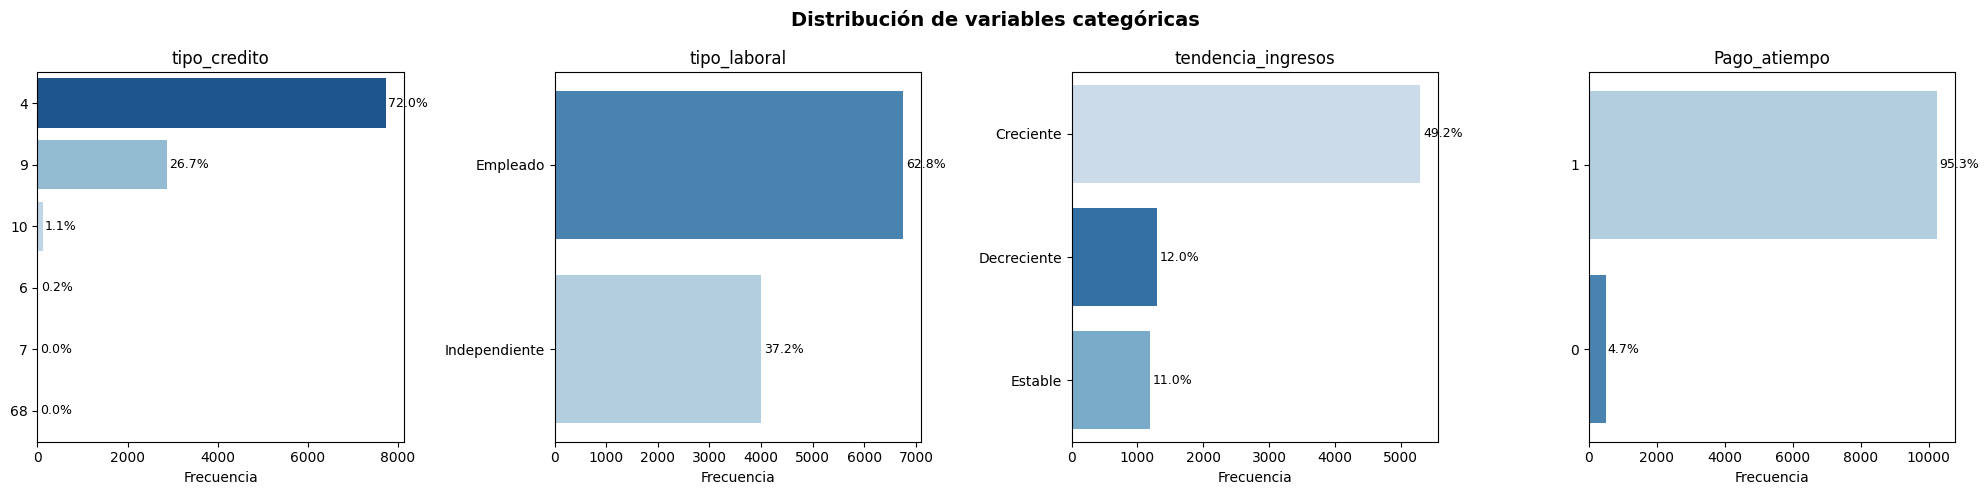


--- tipo_credito ---
              count      %
tipo_credito              
4              7747  71.98
9              2876  26.72
10              116   1.08
6                21   0.20
7                 2   0.02
68                1   0.01

--- tipo_laboral ---
               count      %
tipo_laboral               
Empleado        6754  62.75
Independiente   4009  37.25

--- tendencia_ingresos ---
                    count      %
tendencia_ingresos              
Creciente            5294  68.11
Decreciente          1291  16.61
Estable              1188  15.28

--- Pago_atiempo ---
              count      %
Pago_atiempo              
1             10252  95.25
0               511   4.75


In [14]:
# Variables categóricas — countplot
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
fig.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden, ax=axes[i], 
                  palette='Blues_r', hue=col, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')
    
    # Anotamos porcentajes
    total = len(df)
    for p in axes[i].patches:
        pct = f'{100 * p.get_width() / total:.1f}%'
        axes[i].annotate(pct, (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tablas de frecuencia
for col in cat_cols:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    print(pd.concat([vc, pct.rename('%')], axis=1).to_string())

__🔍Observaciones:__   
- puntaje: puede ser el predictor más poderoso, la media del grupo mora (23.1) es 4 veces menor que la del grupo pago puntual (94.6), una diferencia de +309%. Esto indica que el score interno discrimina muy bien el riesgo.
- saldo_mora: tiene diferencia negativa (-X%): los clientes en mora tienen mayor saldo moroso, lo cual es esperable y confirma que la variable captura correctamente el comportamiento de impago.
- huella_consulta: también es negativa: más consultas al buró se asocian con mayor mora, un patrón de búsqueda  de crédito.
- creditos_sectorCooperativo y promedio_ingresos_datacredito: muestran diferencias positivas moderadas, sugiriendo que quienes tienen historial en cooperativas y mayores ingresos reportados al buró tienden a pagar mejor.

In [ ]:
# Pivote rápido: promedio de cada variable numérica según Pago_atiempo
pivot = df.groupby('Pago_atiempo', observed=True)[num_cols].mean().T
pivot.columns = ['Mora (0)', 'Pago puntual (1)']
pivot['diferencia_%'] = ((pivot['Pago puntual (1)'] - pivot['Mora (0)']) 
                          / pivot['Mora (0)'].replace(0, np.nan) * 100).round(1)
pivot = pivot.sort_values('diferencia_%', ascending=False)

print("MEDIA POR CLASE target")
print(pivot.to_string())

MEDIA POR CLASE target
                                   Mora (0)  Pago puntual (1)  diferencia_%
puntaje                        2.309122e+01      9.456335e+01         309.5
creditos_sectorCooperativo     2.015656e-01      2.732150e-01          35.5
promedio_ingresos_datacredito  1.605742e+06      2.023448e+06          26.0
saldo_total                    3.907492e+04      4.627690e+04          18.4
creditos_sectorFinanciero      2.516634e+00      2.793114e+00          11.0
saldo_principal                3.664643e+04      4.052673e+04          10.6
edad_cliente                   4.177299e+01      4.405706e+01           5.5
puntaje_datacredito            7.488804e+02      7.823790e+02           4.5
cant_creditosvigentes          5.569472e+00      5.734588e+00           3.0
mes_prestamo                   5.127202e+00      5.281409e+00           3.0
año_prestamo                   2.024859e+03      2.024895e+03           0.0
cuota_pactada                  2.547557e+05      2.430622e+05    

__🔍Observaciones:__   
Las variables con mayor diferencia_% son las más prometedoras como predictores, como por ejemplo, puntaje, creditos_sectorCoperativo, promedio_ingresos_datacredito.

In [23]:
# Detección de outliers por método IQR
def contar_outliers(df, col):
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    return {'outliers': outliers, 'outliers_%': round(outliers / len(data) * 100, 2)}

outliers_df = pd.DataFrame(
    {col: contar_outliers(df, col) for col in num_cols}
).T.sort_values('outliers_%', ascending=False)

print("=== OUTLIERS POR VARIABLE (método IQR) ===")
print(outliers_df[outliers_df['outliers'] > 0].to_string())

=== OUTLIERS POR VARIABLE (método IQR) ===
                               outliers  outliers_%
creditos_sectorCooperativo       1895.0       17.61
año_prestamo                     1656.0       15.39
puntaje                          1356.0       12.60
promedio_ingresos_datacredito     784.0       10.01
saldo_principal                   951.0        9.18
saldo_total                       970.0        9.14
plazo_meses                       869.0        8.07
cuota_pactada                     765.0        7.11
salario_cliente                   718.0        6.67
total_otros_prestamos             589.0        5.47
capital_prestado                  550.0        5.11
creditos_sectorFinanciero         364.0        3.38
creditos_sectorReal               350.0        3.25
cant_creditosvigentes             242.0        2.25
huella_consulta                   216.0        2.01
puntaje_datacredito               196.0        1.82
edad_cliente                      150.0        1.39
saldo_mora           

---

### <font color="#F5AD27">__Análisis Bivariado__</font>
---

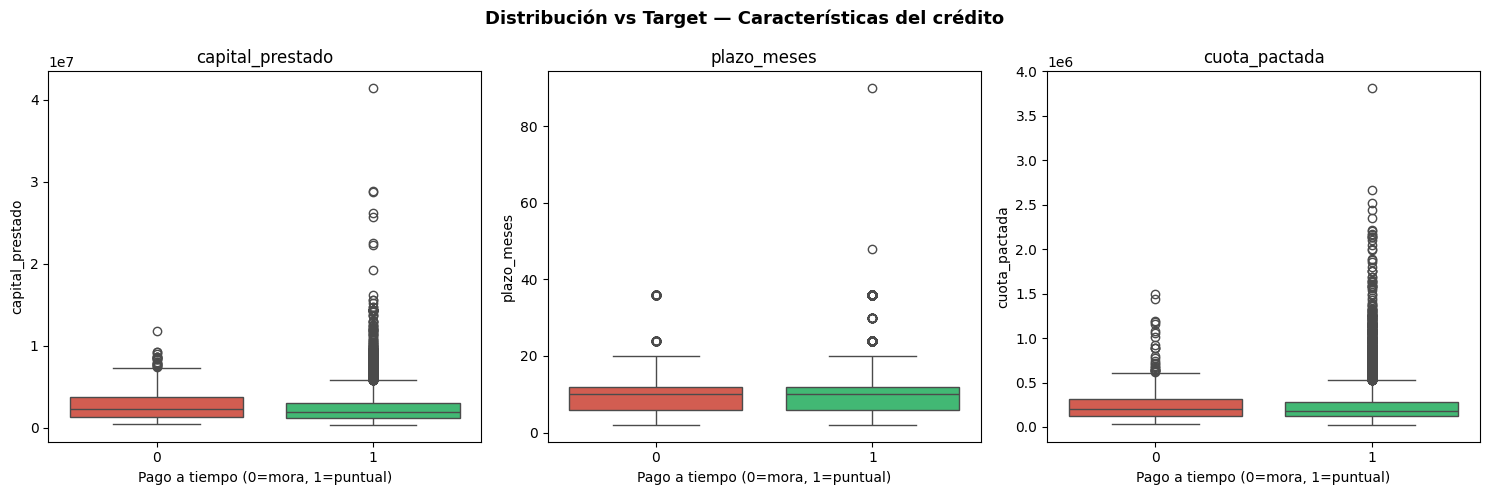

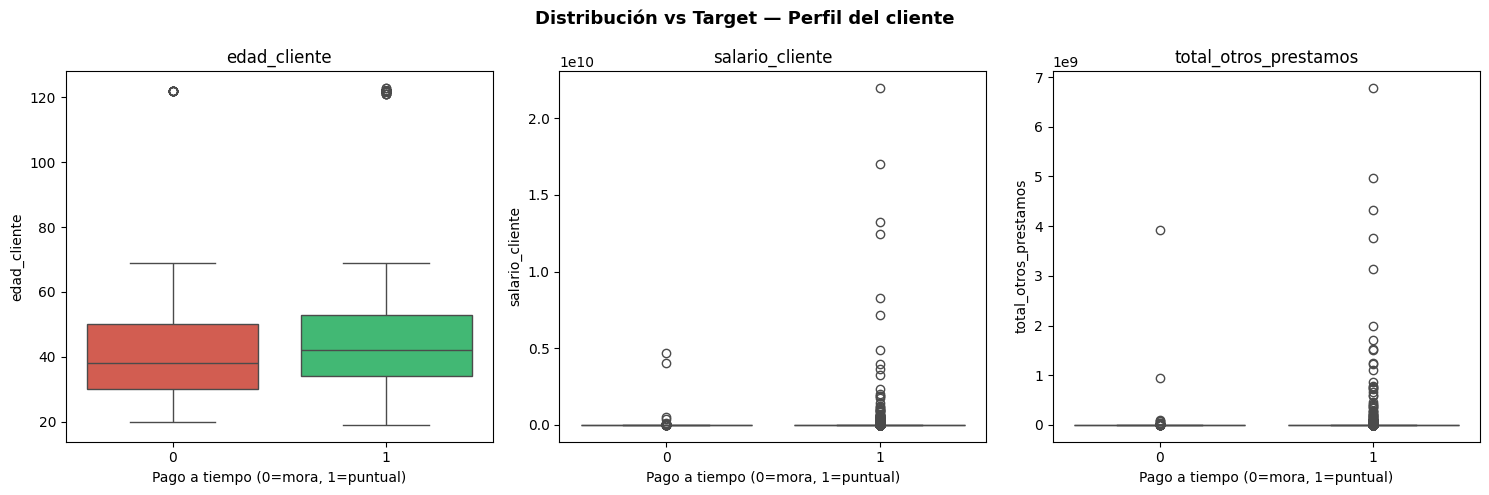

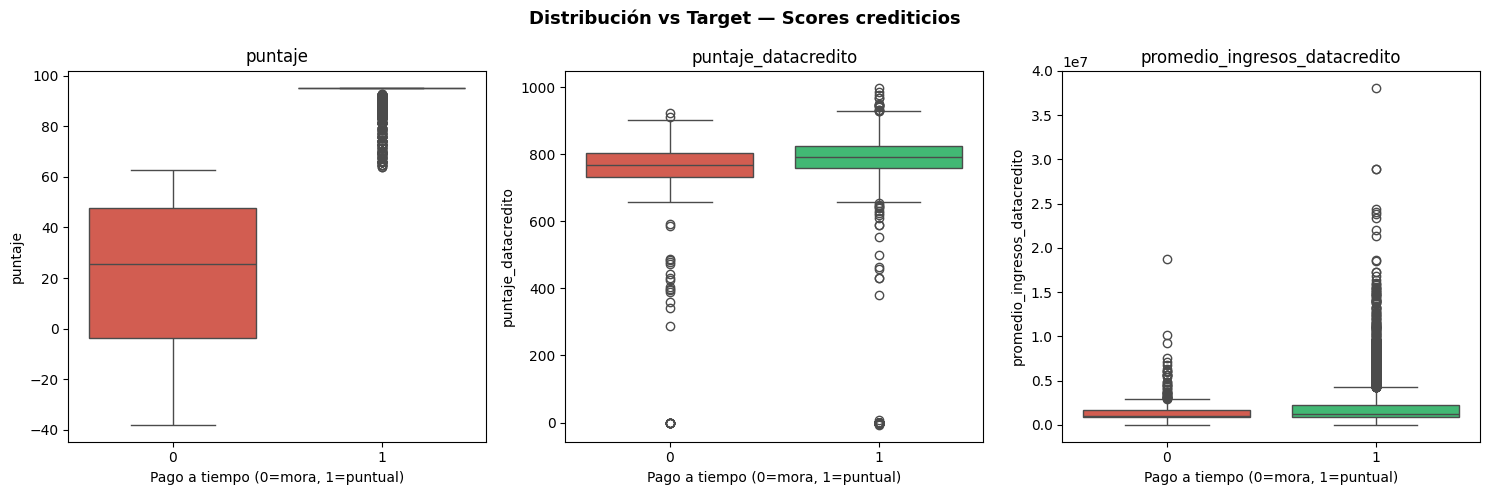

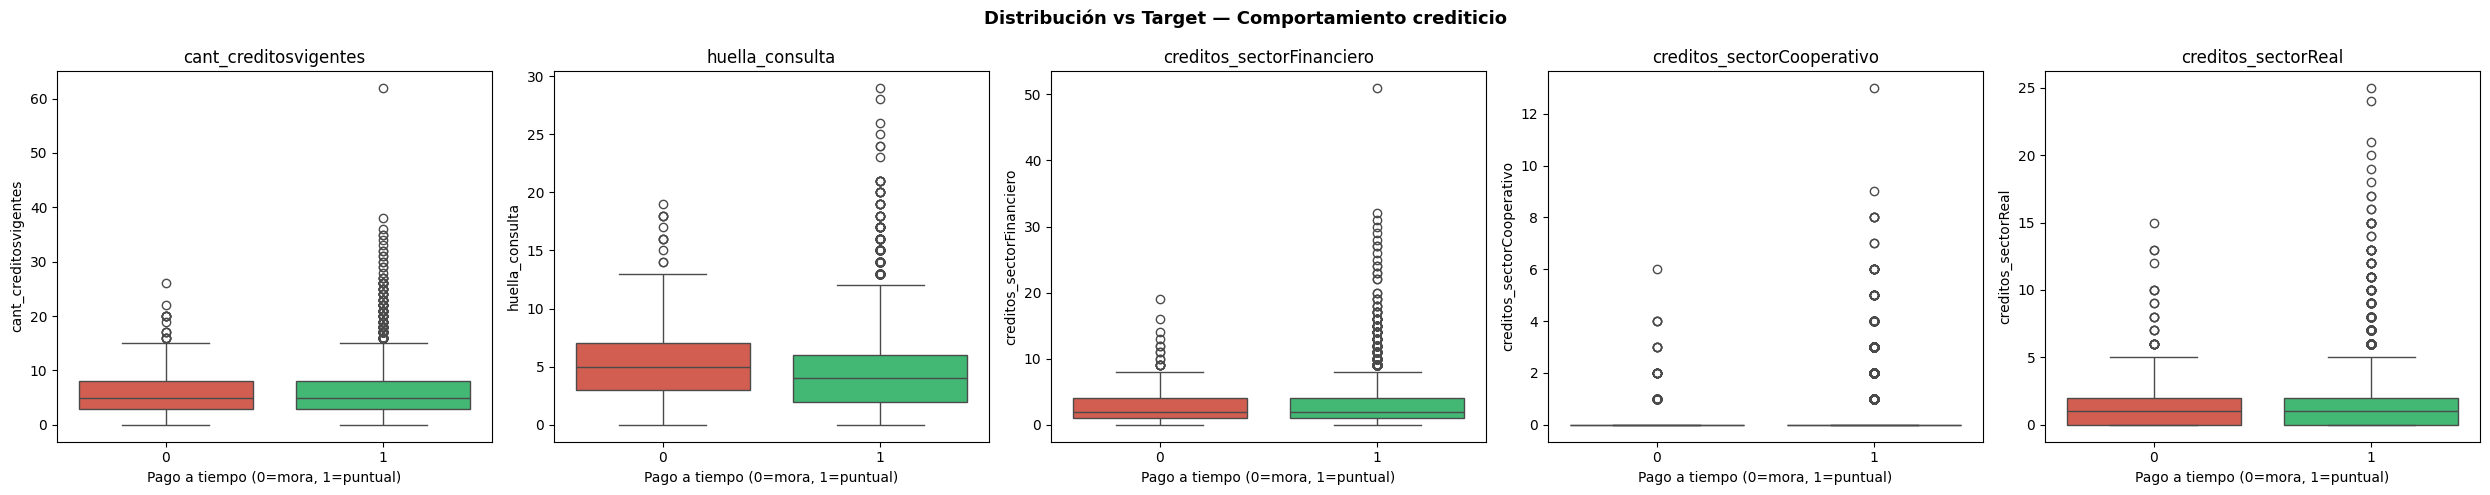

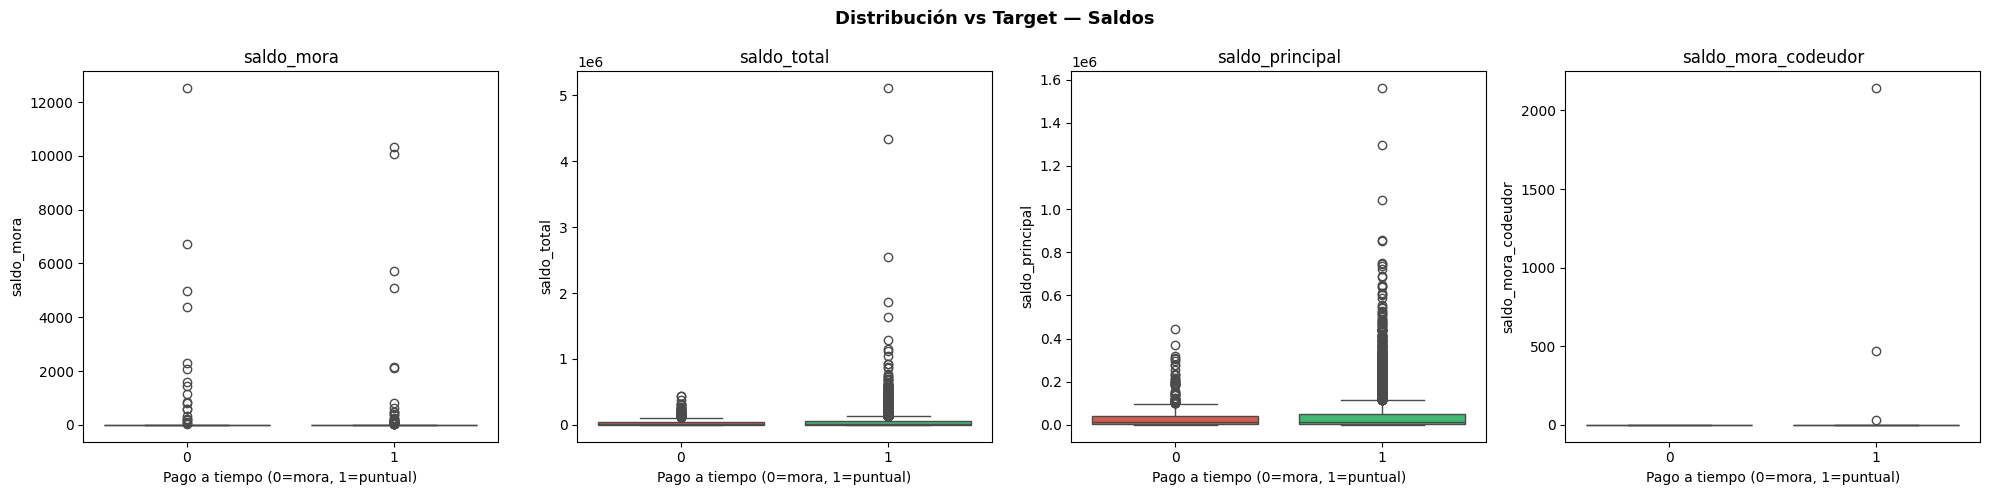

In [16]:
# Comparamos distribución de cada variable numérica según el target
for grupo, cols in grupos.items():
    fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 5))
    fig.suptitle(f'Distribución vs Target — {grupo}', fontsize=13, fontweight='bold')
    
    for i, col in enumerate(cols):
        sns.boxplot(data=df, x='Pago_atiempo', y=col, ax=axes[i],
                    hue='Pago_atiempo', palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
        axes[i].set_title(col)
        axes[i].set_xlabel('Pago a tiempo (0=mora, 1=puntual)')
    
    plt.tight_layout()
    plt.show()

__🔍Observaciones:__  
Se observa una diferencia clara en la mediana entre clase 0 y clase 1 de la variable puntaje vs variable target, pudiendo indicar que sea un predictor candidato.

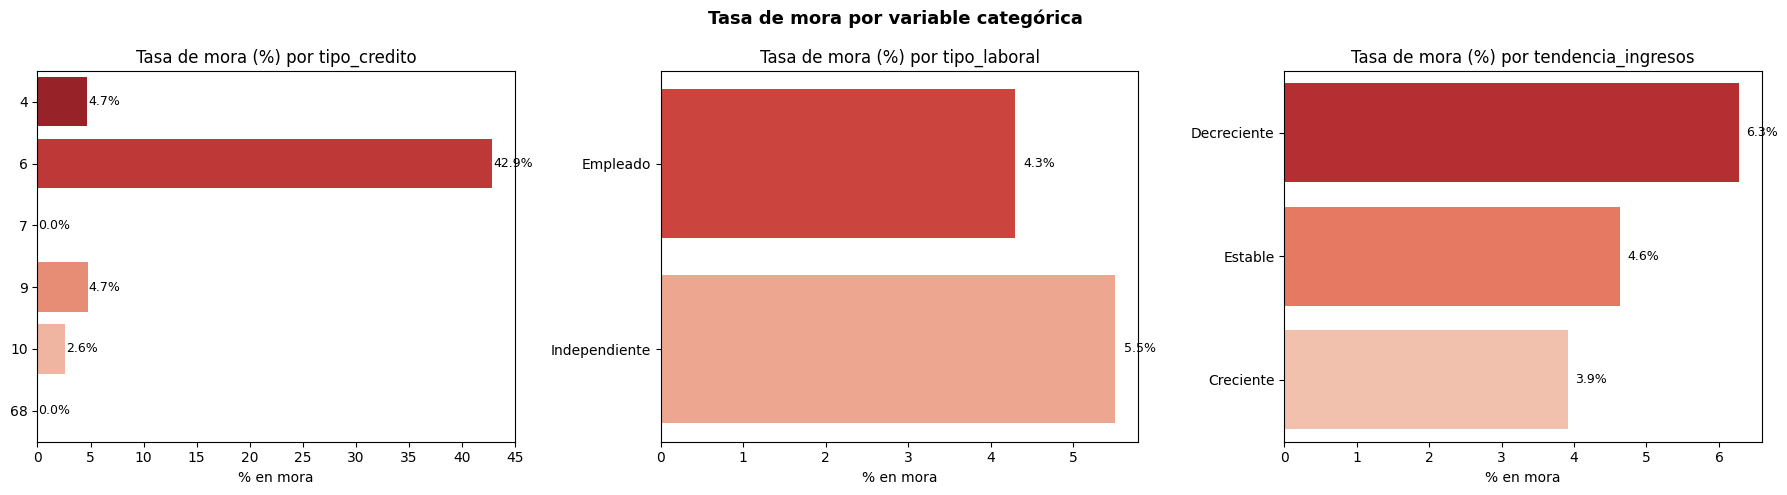


=== Tabla cruzada: tipo_credito vs Pago_atiempo ===
Pago_atiempo  mora_%  pago_puntual_%
tipo_credito                        
4               4.69           95.31
6              42.86           57.14
7               0.00          100.00
9               4.73           95.27
10              2.59           97.41
68              0.00          100.00
All             4.75           95.25

=== Tabla cruzada: tipo_laboral vs Pago_atiempo ===
Pago_atiempo   mora_%  pago_puntual_%
tipo_laboral                         
Empleado         4.29           95.71
Independiente    5.51           94.49
All              4.75           95.25

=== Tabla cruzada: tendencia_ingresos vs Pago_atiempo ===
Pago_atiempo        mora_%  pago_puntual_%
tendencia_ingresos                        
Decreciente           6.27           93.73
Estable               4.63           95.37
Creciente             3.91           96.09
All                   4.41           95.59


In [17]:
# Para cada categórica (excepto el target), vemos cómo se distribuye el target dentro
cat_features = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']

fig, axes = plt.subplots(1, len(cat_features), figsize=(6 * len(cat_features), 5))
fig.suptitle('Tasa de mora por variable categórica', fontsize=13, fontweight='bold')

for i, col in enumerate(cat_features):
    tasa_mora = (df.groupby(col, observed=True)['Pago_atiempo']
                   .apply(lambda x: (x == 0).sum() / len(x) * 100)
                   .sort_values(ascending=False)
                   .reset_index())
    tasa_mora.columns = [col, 'tasa_mora_%']
    
    sns.barplot(data=tasa_mora, x='tasa_mora_%', y=col, ax=axes[i],
                palette='Reds_r', hue=col, legend=False)
    axes[i].set_title(f'Tasa de mora (%) por {col}')
    axes[i].set_xlabel('% en mora')
    axes[i].set_ylabel('')
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_width():.1f}%',
                         (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tablas cruzadas
for col in cat_features:
    print(f"\n=== Tabla cruzada: {col} vs Pago_atiempo ===")
    tabla = pd.crosstab(df[col], df['Pago_atiempo'], 
                        margins=True, normalize='index').mul(100).round(2)
    tabla.columns = tabla.columns.map({0: 'mora_%', 1: 'pago_puntual_%', 'Total': 'total_%'})

    print(tabla.to_string())

__🔍Observaciones:__  
- tipo_credito vs Pago_atiempo: la categoría 6 presenta mora muy alta, pudiendo ser el grupo de mayor riesgo.
- tipo_laboral vs Pago_atiempo: la categoría independiente presenta mayor cantidad de mora.
- tendencia_ingresos vs Pago_atiempo: clientes con tendencia decreciente presenta mayor mora.

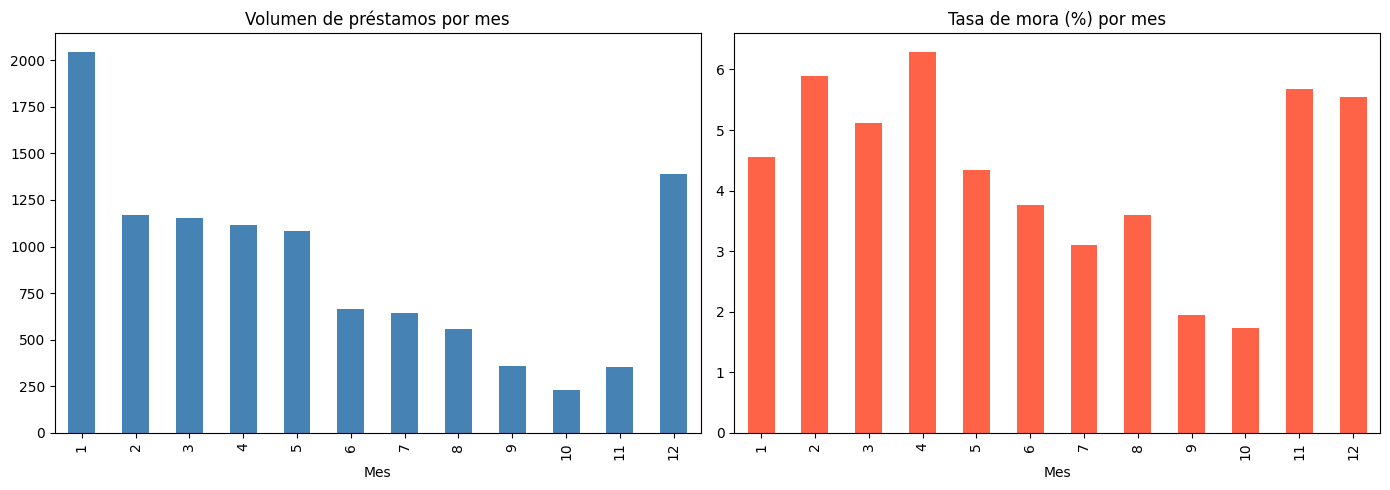

In [25]:
# Distribución temporal de préstamos y tasa de mora por mes/año
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volumen por mes
df.groupby('mes_prestamo').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Volumen de préstamos por mes')
axes[0].set_xlabel('Mes')

# Tasa de mora por mes
mora_mes = df.groupby('mes_prestamo')['Pago_atiempo'].apply(
    lambda x: (x.astype(int) == 0).sum() / len(x) * 100
)
mora_mes.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Tasa de mora (%) por mes')
axes[1].set_xlabel('Mes')

plt.tight_layout()
plt.show()

__🔍Observaciones:__  
- Los meses enero y diciembre son aquellos que presentan mayor cantidad de préstamos por mes.
- Los meses abril, febrero, noviembre y diciembre son aquellos que presentan mayor tasa de mora.

### <font color="#F5AD27">__Análisis Multivariado__</font>
---

=== CORRELACIÓN CON EL TARGET (Pago_atiempo) ===
huella_consulta                 -0.073737
saldo_mora                      -0.073458
plazo_meses                     -0.063105
capital_prestado                -0.040624
creditos_sectorReal             -0.023306
cuota_pactada                   -0.011814
total_otros_prestamos           -0.010041
salario_cliente                 -0.003981
saldo_mora_codeudor              0.002631
mes_prestamo                     0.008822
cant_creditosvigentes            0.008829
saldo_principal                  0.011473
saldo_total                      0.014364
año_prestamo                     0.020251
creditos_sectorCooperativo       0.021267
creditos_sectorFinanciero        0.021390
edad_cliente                     0.032252
promedio_ingresos_datacredito    0.039867
puntaje_datacredito              0.067882
puntaje                          0.923134


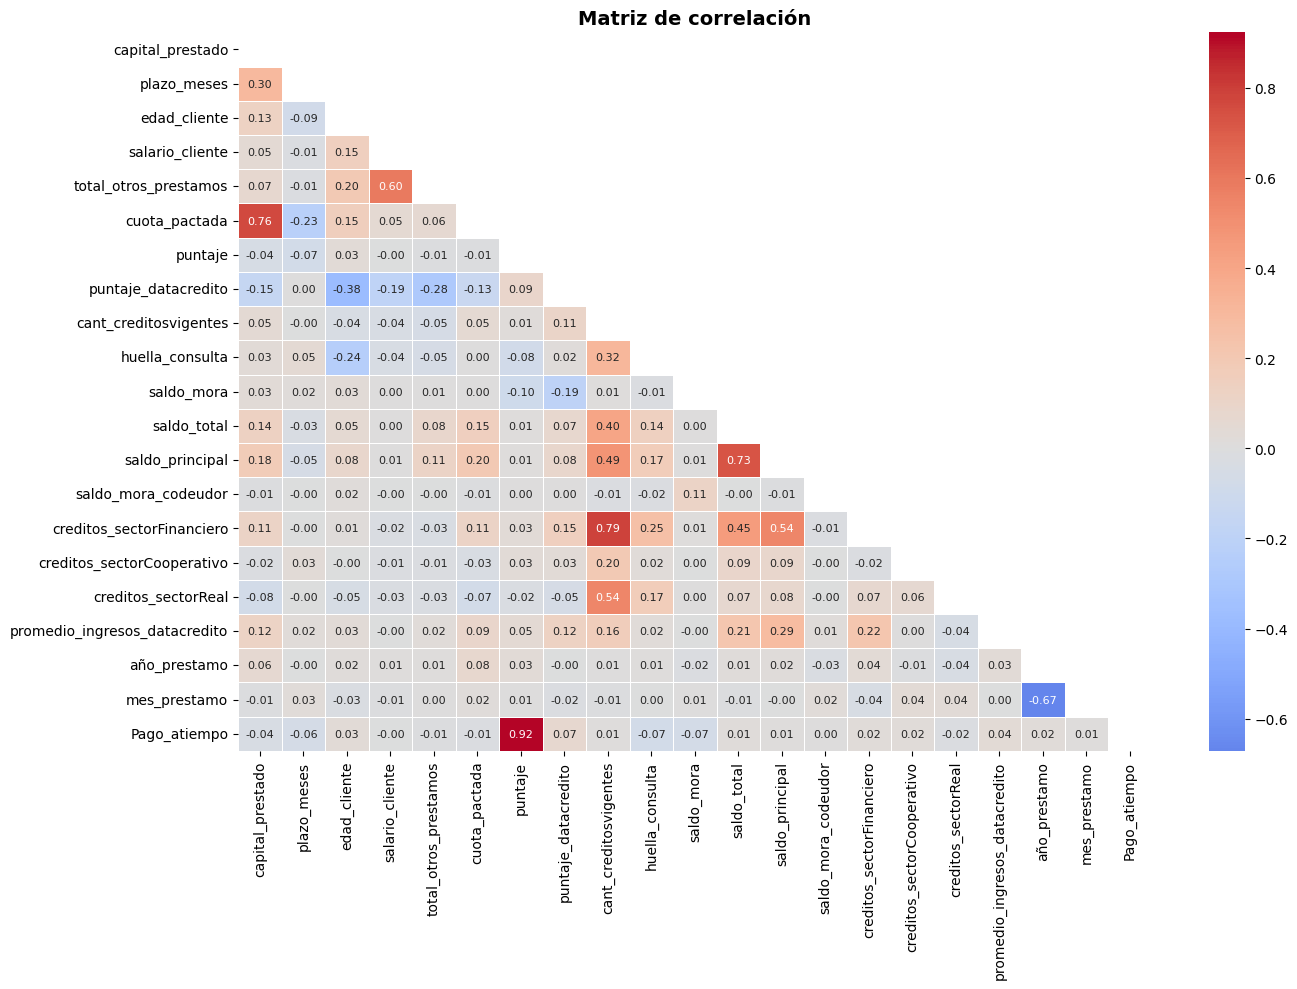

In [18]:
# Convertimos el target a int para incluirlo en la correlación
corr_df = df[num_cols].copy()
corr_df['Pago_atiempo'] = df['Pago_atiempo'].astype(int)

corr_matrix = corr_df.corr()

# Correlaciones con el target ordenadas
print("=== CORRELACIÓN CON EL TARGET (Pago_atiempo) ===")
print(corr_matrix['Pago_atiempo'].drop('Pago_atiempo')
      .sort_values()
      .to_string())

# Heatmap completo
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

__🔍Observaciones:__  

- puntaje: tiene la correlación más fuerte con el target  es el predictor dominante del dataset.
- puntaje_datacredito: también correlaciona positivamente, pero en menor medida, sugiriendo que el score interno captura información adicional no presente en el buró externo.
- huella_consulta y saldo_mora: correlacionan negativamente.
- saldo_total, saldo_principal y capital_prestado están altamente correlacionados entre sí (probable multicolinealidad), lo que habrá que manejar en feature engineering.
- Las correlaciones lineales en general son bajas (excepto puntaje), lo que sugiere que modelos no lineales como Random Forest o XGBoost podrían capturar mejor las relaciones.


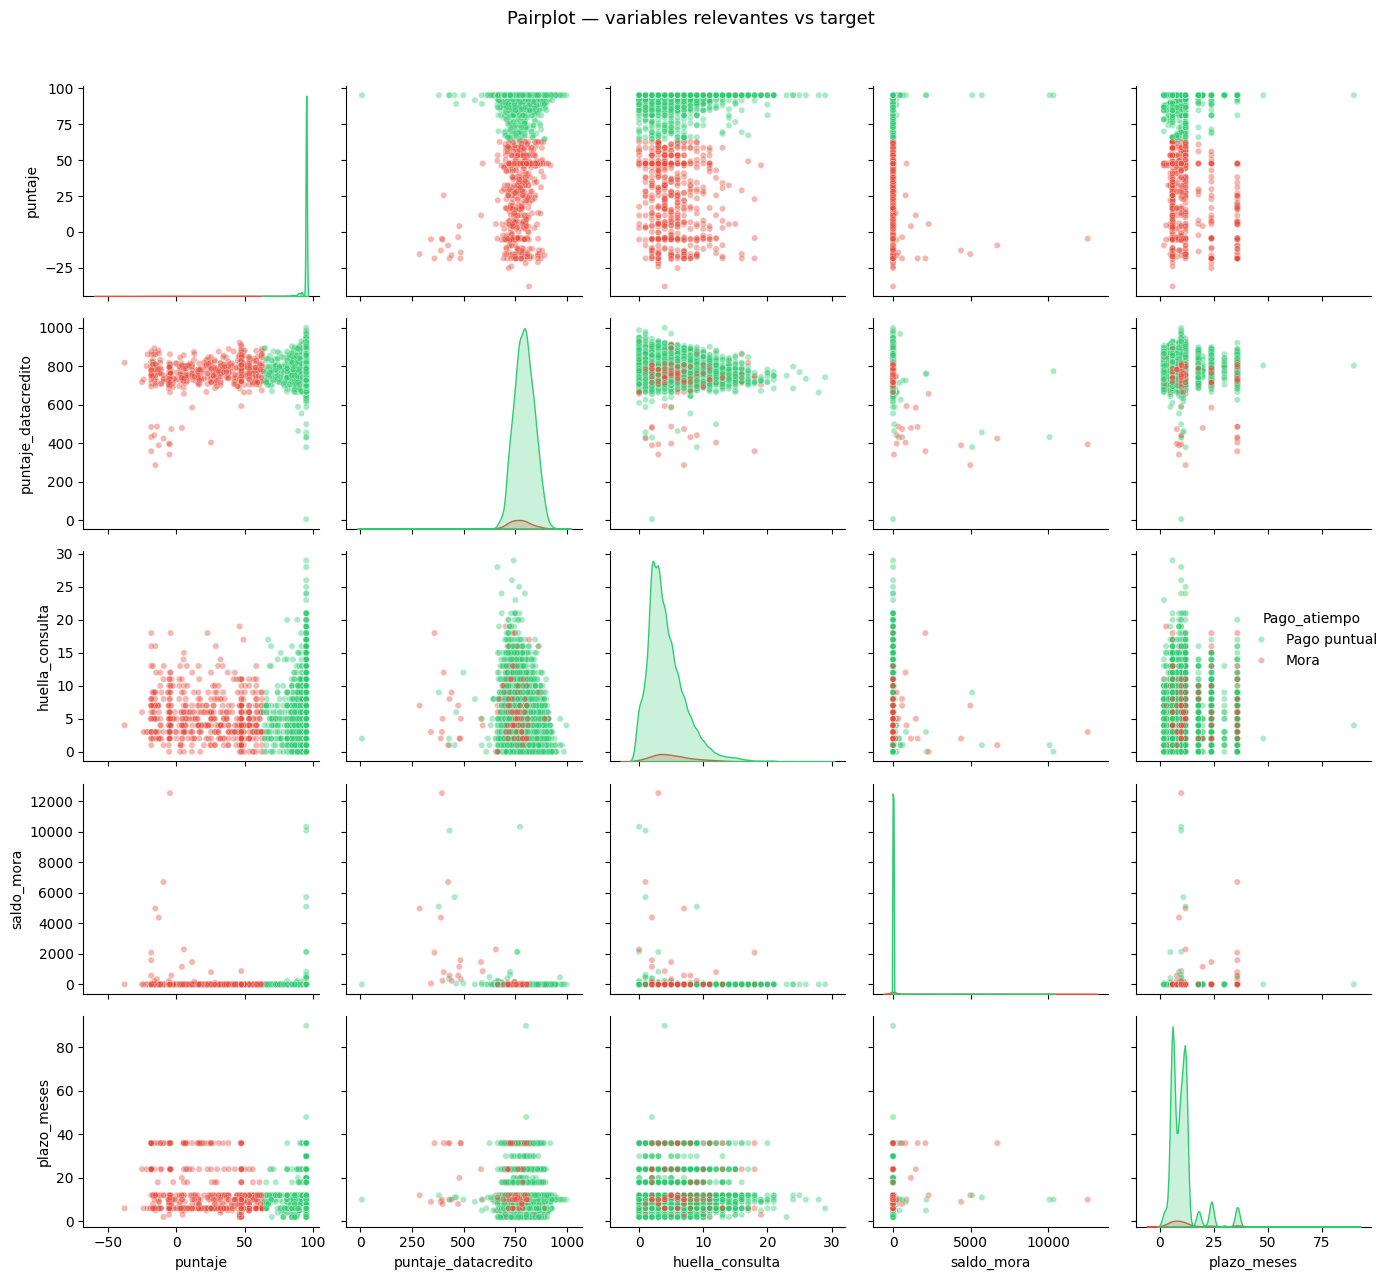

In [ ]:
# Pairplot con las variables más prometedoras (elegimos las de mayor correlación con target)
vars_relevantes = ['puntaje', 'puntaje_datacredito', 'huella_consulta',
                   'saldo_mora', 'plazo_meses']

pair_df = df[vars_relevantes + ['Pago_atiempo']].dropna()
pair_df['Pago_atiempo'] = pair_df['Pago_atiempo'].astype(str).map({'0': 'Mora', '1': 'Pago puntual'})

g = sns.pairplot(pair_df, hue='Pago_atiempo', 
                 palette={'Mora': '#e74c3c', 'Pago puntual': '#2ecc71'},
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — variables relevantes vs target', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

__🔍Observaciones:__  
En algunas variables como puntaje y saldo_mora en la diagonal, presentan separación entre las distribuciones de ambas clases, pudiendo indicar que la variable es discriminativa para el modelo. 

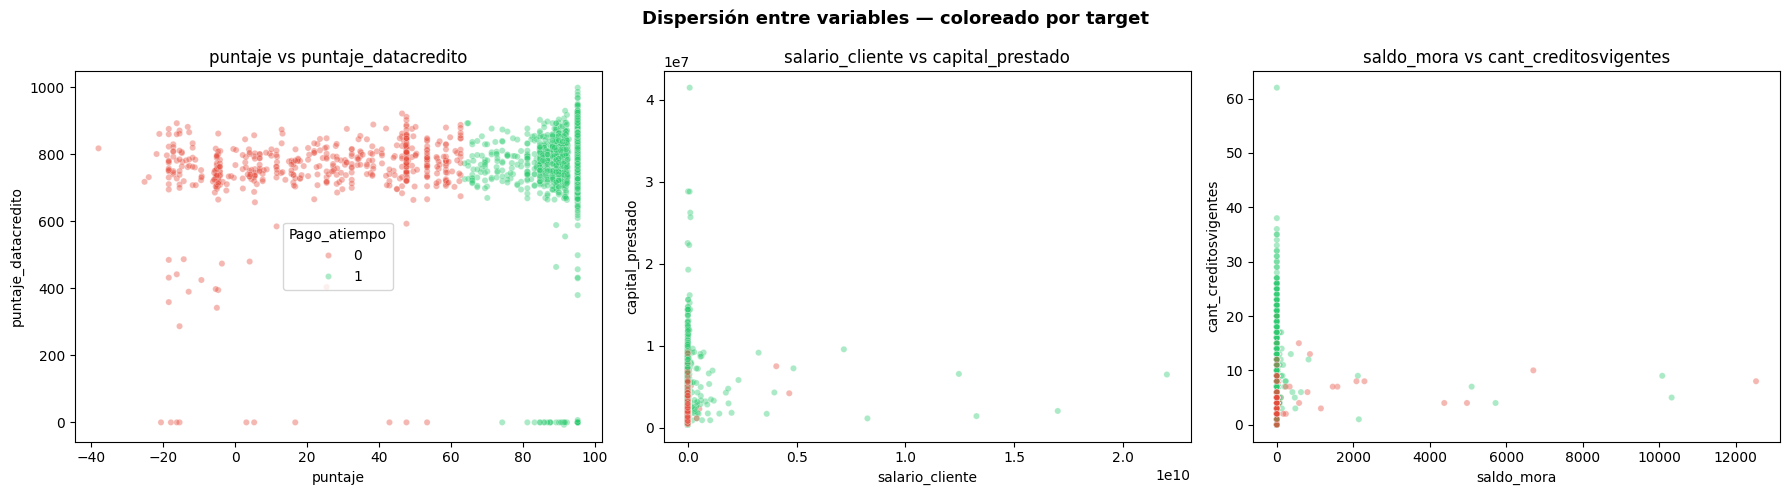

In [20]:
# Scatterplots entre pares de variables de alto interés, coloreados por target
pares = [
    ('puntaje', 'puntaje_datacredito'),
    ('salario_cliente', 'capital_prestado'),
    ('saldo_mora', 'cant_creditosvigentes'),
]

fig, axes = plt.subplots(1, len(pares), figsize=(6 * len(pares), 5))
fig.suptitle('Dispersión entre variables — coloreado por target', fontsize=13, fontweight='bold')

palette = {0: '#e74c3c', 1: '#2ecc71'}
for i, (x, y) in enumerate(pares):
    sns.scatterplot(data=df.dropna(subset=[x, y]), x=x, y=y,
                    hue='Pago_atiempo', palette=palette,
                    alpha=0.4, s=20, ax=axes[i], legend=(i == 0))
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

__🔍Observaciones:__  
En el scatterplot de las variables puntaje vs puntaje_datacredito se observa dos clusters diferenciados.

---

#### <font color="#F5AD27">__Reglas de validación de datos (para usar en model_monitoring.py)__</font>
---

| Variable | Regla | Acción si se viola |
|---|---|---|
| edad_cliente | entre 18 y 90 | rechazar registro |
| capital_prestado | > 0 | rechazar registro |
| plazo_meses | > 0 y número entero | rechazar registro |
| salario_cliente | > 0 | rechazar registro |
| puntaje | entre 0 y 100 | flag de alerta |
| puntaje_datacredito | entre 0 y 1000 | flag de alerta |
| tipo_laboral | solo 'Empleado' o 'Independiente' | rechazar / imputar |
| tendencia_ingresos | solo 'Creciente', 'Estable', 'Decreciente' | imputar con moda |
| cuota_pactada | > 0 | rechazar registro |
| promedio_ingresos_datacredito | >=0 | flag de alerta |
| cant_creditosvigentes | >=0 | flag de alerta |



#### <font color="#F5AD27">__Posibles transformaciones identificadas para ft_engineering.py__</font>
- **Log transform (log1p)**: `capital_prestado`, `salario_cliente`, `saldo_mora`, `saldo_total` — usar np.log1p() para manejar ceros.
- **Imputación numérica**: `puntaje_datacredito` → mediana; `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor` → 0; `promedio_ingresos_datacredito` → mediana (o crear flag binario `tiene_historial_buro`)
- **Imputación categórica**: `tendencia_ingresos` → nueva categoría `'Sin_historial'` (los nulos son informativos, no aleatorios)
- **Encoding**: `tipo_laboral` → OrdinalEncoder o binario; `tendencia_ingresos` → OrdinalEncoder (es ordinal); `tipo_credito` → OneHotEncoder
- **Feature derivado**: ratio `cuota_pactada / salario_cliente` (carga financiera) — aplicar solo donde salario > 0, imputar con mediana del grupo en el resto.
- **Drop en producción**: `fecha_prestamo` original (reemplazada por `año_prestamo` y `mes_prestamo`)
- **Desbalance de clases**: ~95/5 → aplicar `class_weight='balanced'` o SMOTE.

---